In [1]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
import random
import numpy as np

In [2]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

# from model import SeqNN
from akita_model.model import SeqNN

In [3]:
TARGET_C = -0.5

In [4]:
df = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_repeated/only_successful_seqs.tsv", sep="\t")

In [5]:
class OriginalDataset(Dataset):
    def __init__(self, coord_df, init_seq_path):
        self.coords = coord_df
        self.init_seq_path = init_seq_path
    
    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        row = self.coords.iloc[idx]
        chrom = row["chrom"]
        start = row["centered_start"]
        end = row["centered_end"]
        fold = row["fold"]
        
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        
        X = torch.load(f"{self.init_seq_path}/fold{fold}/{chrom}_{start}_{end}_X.pt", weights_only=True, map_location=device)
        X = X.squeeze(0)
        return X

In [6]:
class SyntheticHomopolymerDataset(Dataset):
    def __init__(self, coord_df, init_seq_path, num_hp=60, hp_len=3, seed=42):
        self.coords = coord_df
        self.init_seq_path = init_seq_path
        self.num_hp = num_hp
        self.hp_len = hp_len
        self.seed = seed # For reproducibility of the random G vs C choice
        
        # OHE Mapping (Standard: 0:A, 1:C, 2:G, 3:T)
        self.C_IDX = 1
        self.G_IDX = 2
        
        # Bin 320 constants
        self.bin_size = 2048
        self.target_bin = 320
        self.bin_start_idx = self.target_bin * self.bin_size # 655,360

    def __len__(self):
        return len(self.coords)

    def _insert_homopolymers(self, x):
        """Modifies the tensor in-place to add G/C blocks."""
        # Use a local RNG seeded with the sample index + global seed 
        # so each sequence gets a consistent but unique pattern
        rng = np.random.default_rng(self.seed)
        
        spacing = self.bin_size // self.num_hp
        
        for i in range(self.num_hp):
            pos_in_bin = i * spacing
            abs_pos = self.bin_start_idx + pos_in_bin
            
            if pos_in_bin + self.hp_len >= self.bin_size:
                break
            
            # Choose G or C
            base_idx = rng.choice([self.C_IDX, self.G_IDX])
            
            # Apply to tensor: Zero out all 4 channels, then set the target
            x[:, abs_pos : abs_pos + self.hp_len] = 0
            x[base_idx, abs_pos : abs_pos + self.hp_len] = 1
            
        return x

    def __getitem__(self, idx):
        row = self.coords.iloc[idx]
        chrom = row["chrom"]
        start = row["centered_start"]
        end = row["centered_end"]
        fold = row["fold"]
        
        # Load from disk
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        path = f"{self.init_seq_path}/fold{fold}/{chrom}_{start}_{end}_X.pt"
        
        X = torch.load(path, weights_only=True, map_location=device)
        X = X.squeeze(0) # Shape becomes (4, 1310720)
        
        # Apply the synthetic modification
        X_modified = self._insert_homopolymers(X)
        
        return X_modified

In [7]:
def set_diag(matrix, value, k):
    """Set diagonal `k` of a matrix to `value`."""
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu_batch(batch_vectors, matrix_len=512, num_diags=2):
    """Convert a batch of upper-triangular vectors into symmetric matrices with np.nan on diagonals."""
    if isinstance(batch_vectors, torch.Tensor):
        batch_vectors = batch_vectors.detach().cpu().numpy()

    batch_size = len(batch_vectors)
    matrices = np.zeros((batch_size, matrix_len, matrix_len), dtype=np.float32)

    triu_indices = np.triu_indices(matrix_len, num_diags)

    for i in range(batch_size):
        matrices[i][triu_indices] = batch_vectors[i][0,:]
        # Mirror to lower triangle
        matrices[i] = matrices[i] + matrices[i].T

        # Set diagonals to np.nan
        for k in range(-num_diags + 1, num_diags):
            set_diag(matrices[i], np.nan, k)

    return matrices  # shape: [B, 512, 512]

In [8]:
orig_dataset = OriginalDataset(df, f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/generate_genomic_boundary/ohe_X")

orig_loader = DataLoader(orig_dataset, batch_size=4, shuffle=False)

In [9]:
synthetic_loader = DataLoader(
    SyntheticHomopolymerDataset(df, f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/generate_genomic_boundary/ohe_X"), 
    batch_size=4, 
    shuffle=False
)

In [10]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [11]:
model = SeqNN()
model_path = (
    "/home1/smaruj/pytorch_akita/models/finetuned/mouse/Hsieh2019_mESC/checkpoints/Akita_v2_mouse_Hsieh2019_mESC_model0_finetuned.pth"
)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()


SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [12]:
slice = 256
cropping = 64
bin_size = 2048

edit_start = (slice + cropping) * bin_size
edit_end = edit_start + bin_size

In [13]:
preds_all_orig = []
preds_all_reversed = []
urq_init_values = []
urq_mean_values = []

model.eval()
with torch.no_grad():
    for orig_batch, edited_batch in zip(orig_loader, synthetic_loader):
        orig_batch = orig_batch.to(device)
        edited_batch = edited_batch.to(device)

        preds_orig = model(orig_batch).cpu()
        preds_edited = model(edited_batch).cpu()

        # preds_all_orig.extend(preds_orig)
        # preds_all_reversed.extend(preds_edited)
        
        orig_maps = from_upper_triu_batch(preds_orig)
        edited_maps = from_upper_triu_batch(preds_edited)
        
        urq_init = np.nanmean(orig_maps[:, 0:250, 260:512], axis=(1, 2))
        urq_init_values.extend(urq_init)
        
        urq_mean = np.nanmean(edited_maps[:, 0:250, 260:512], axis=(1, 2))
        urq_mean_values.extend(urq_mean)
        

/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv1d(input, weight, bias, self.stride,


In [14]:
df["URQ_flat"] = urq_init_values
df["URQ_homopolymers"] = urq_mean_values

In [15]:
df["URQ_flat"].mean()

-0.045866095

In [16]:
df["URQ_homopolymers"].mean()

-0.045499615

In [21]:
class SyntheticSINEB2Dataset(Dataset):
    def __init__(self, coord_df, init_seq_path, consensus_str, num_repeats=10):
        self.coords = coord_df
        self.init_seq_path = init_seq_path
        self.num_repeats = num_repeats
        
        # Bin 320 constants
        self.bin_size = 2048
        self.target_bin = 320
        self.bin_start_idx = self.target_bin * self.bin_size
        
        # Mapping: 0:A, 1:C, 2:G, 3:T
        self.base_to_idx = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
        
        # Pre-encode the consensus to OHE (4, 196)
        self.b2_ohe = self._string_to_ohe(consensus_str)
        self.b2_len = self.b2_ohe.shape[1]

    # --- THE MISSING PIECE ---
    def __len__(self):
        return len(self.coords)
    # -------------------------

    def _string_to_ohe(self, seq_str):
        """Converts a DNA string to a (4, L) OHE tensor."""
        seq_len = len(seq_str)
        ohe = torch.zeros((4, seq_len))
        for i, base in enumerate(seq_str.upper()):
            if base in self.base_to_idx:
                ohe[self.base_to_idx[base], i] = 1
        return ohe

    def _insert_sine_elements(self, x):
        """Tiles the B2 elements into the central bin."""
        gap = 8 
        for i in range(self.num_repeats):
            start_in_bin = i * (self.b2_len + gap)
            abs_start = self.bin_start_idx + start_in_bin
            abs_end = abs_start + self.b2_len
            
            if start_in_bin + self.b2_len > self.bin_size:
                break
                
            x[:, abs_start:abs_end] = 0
            x[:, abs_start:abs_end] = self.b2_ohe
        return x

    def __getitem__(self, idx):
        row = self.coords.iloc[idx]
        chrom = row["chrom"]
        start = row["centered_start"]
        end = row["centered_end"]
        fold = row["fold"]
        
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        path = f"{self.init_seq_path}/fold{fold}/{chrom}_{start}_{end}_X.pt"
        
        X = torch.load(path, weights_only=True, map_location=device)
        X = X.squeeze(0)
        
        # Always clone before modifying to prevent original data corruption
        X_modified = self._insert_sine_elements(X.clone())
        
        return X_modified

In [22]:
SINEB2_consensus = "GGGGCTGGAGAGATGGCTCAGCGGTTAAGAGCACTGACTGCTCTTCCAGAGGTCCTGAGTTCAATTCCCAGCAACCACATGGTGGCTCACAACCATCTGTAATGGGATCTGATGCCCTCTTCTGGTGTGTCTGAAGACAGCTACAGTGTACTCACATACATAAATAAATAAATAAATAAATCTTTAAAAAAAAAAAAAA"

In [23]:
sineb2_dataset = SyntheticSINEB2Dataset(df, f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/generate_genomic_boundary/ohe_X", SINEB2_consensus)

sineb2_loader = DataLoader(sineb2_dataset, batch_size=4, shuffle=False)

In [24]:
urq_sineb2_values = []

model.eval()
with torch.no_grad():
    for edited_batch in sineb2_loader:
        edited_batch = edited_batch.to(device)
        
        preds_edited = model(edited_batch).cpu()

        edited_maps = from_upper_triu_batch(preds_edited)
        
        urq_mean = np.nanmean(edited_maps[:, 0:250, 260:512], axis=(1, 2))
        urq_sineb2_values.extend(urq_mean)
        

In [25]:
df["URQ_sineB2"] = urq_sineb2_values

In [26]:
df["URQ_sineB2"].mean()

-0.05793955

In [28]:
df.to_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_repeated/only_successful_seqs_homopolymers_sineb2.tsv", sep="\t", index=False)

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
df.columns

Index(['chrom', 'fold', 'PearsonR', 'centered_start', 'centered_end',
       'centered_flat_start', 'centered_flat_end', 'active_fraction',
       'neutral_fraction', 'repressive_fraction', 'ctcf_motif_locs',
       'last_accepted_step', 'SCD', 'URQ_result', 'URQ_target', 'URQ_init',
       'num_edits', 'GC_seq', 'GC_slice', 'GC_slice_edited', 'init_CTCFs_num',
       'CTCFs_num', 'avg_orig_fimo_scores', 'avg_new_fimo_scores',
       'orig_CTCFs_coord', 'new_CTCFs_coord', 'avg_orig_left_fimo_scores',
       'avg_new_left_fimo_scores', 'avg_orig_right_fimo_scores',
       'avg_new_right_fimo_scores', 'URQ_diff', 'URQ_flat', 'URQ_homopolymers',
       'URQ_sineB2'],
      dtype='object')

/tmp/SLURM_2662633/ipykernel_409959/2601529135.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


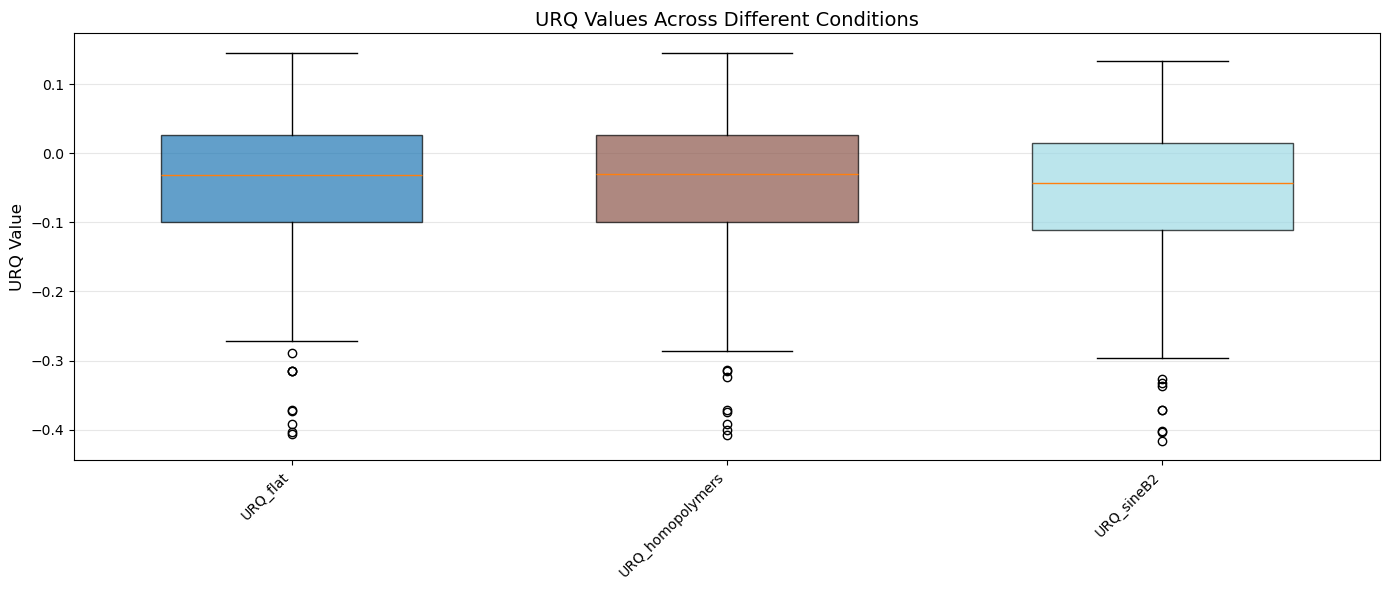

In [30]:
# Define the columns to plot
urq_columns = [
    'URQ_flat',
    'URQ_homopolymers',
    'URQ_sineB2'
]

# Create the boxplot with filled boxes
fig, ax = plt.subplots(figsize=(14, 6))

bp = ax.boxplot(
    [df[col].dropna() for col in urq_columns],
    labels=urq_columns,
    patch_artist=True,
    widths=0.6
)

# Better color scheme - use tab20 which has 20 distinct colors
colors = plt.cm.tab20(np.linspace(0, 1, len(urq_columns)))

# OR manually define colors for better control:
# colors = [
#     '#8dd3c7', '#ffffb3', '#bebada', '#fb8072', '#80b1d3', '#fdb462',
#     '#b3de69', '#fccde5', '#d9d9d9', '#bc80bd', '#ccebc5', '#ffed6f',
#     '#e5c494', '#a6cee3'
# ]

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Customize the plot
ax.set_xticklabels(urq_columns, rotation=45, ha='right')
ax.set_ylabel('URQ Value', fontsize=12)
ax.set_title('URQ Values Across Different Conditions', fontsize=14)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()